# NO_H2 Power System Demo

Showcase for the hydrogen-free stack:
- `src/power_system_core_no_h2.py`: numba core (deficit: interconnect → medium storage → gas CCS with DAC/E-DAC; surplus: medium storage → DAC → curtail).
- `src/power_system_no_h2.py`: user-facing wrapper (run, analyze, cost, plot).

This notebook builds a synthetic daily net-supply series, runs simulations (with and without interconnect imports), and inspects outputs including gas DAC electricity/capture.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.units import Units as U
from src.power_system_no_h2 import PowerSystemNoH2

pd.set_option("display.precision", 3)
pd.set_option("display.max_columns", 20)

## Build synthetic net-supply data
- Daily frequency, one year
- Two renewable capacity columns (150 GW, 220 GW) to show multi-scenario usage
- Positive values = surplus, negative = deficit (TWh/day)
- Amplitudes chosen so deficits stay coverable by medium storage + gas CCS (to avoid simulation returning `None`).

In [2]:

from src.demand_model import predicted_demand, DemandMode
from src.supply_model import daily_renewables_capacity
from src.data import renewable_capacity_factors

# 1) Pulls a daily demand time series using the seasonal demand model based on ERA5 historical data (filtering to the LDZ subset).
demand_df = predicted_demand(mode=DemandMode.SEASONAL, historical="era5", filter_ldz=True)


# 2) Build daily renewable supply for chosen capacities using ERA5-2024 capacity factors (pint[TWh])
daily_cf = renewable_capacity_factors.get_renewable_capacity_factors(source="era5_2024", resample="D")
renewable_capacities = [200 * U.GW, 220 * U.GW]
supply_df = pd.DataFrame(
    {cap.magnitude: daily_renewables_capacity(cap, daily_cf) for cap in renewable_capacities},
    index=daily_cf.index,
)
# supply_df 

# 3) Align by demand and supply date and compute net supply = supply - demand; rename columns to match expected labels
common_idx = supply_df.index.intersection(demand_df.index)
supply_df = supply_df.reindex(common_idx)
demand_df = demand_df.reindex(common_idx)

net_supply_df = supply_df.sub(demand_df["demand"], axis=0)
net_supply_df = net_supply_df.rename(columns=lambda c: f"S-D(TWh),Ren={int(c)}GW")

net_supply_df.head()


,"S-D(TWh),Ren=200GW","S-D(TWh),Ren=220GW"
1979-01-01,-0.5208040872513342,-0.3544143906895627
1979-01-02,-0.32732435572155394,-0.14928251582646412
1979-01-03,0.14575207039275018,0.37269277715941884
1979-01-04,-0.14847085603126464,0.05348736774909124
1979-01-05,-0.49131394439427134,-0.31943670145322445




A **negative** value means that renewable generation **alone** is **insufficient** and the system experiences an **energy deficit** that day.  
A **positive** value means renewables **exceed** demand, producing a **surplus**.



## Instantiate two NO_H2 systems
- `ps_no_h2`: no interconnect imports
- `ps_no_h2_imports`: enable imports using ERA5-based interconnector data

Both use defaults for medium storage and gas CCS from `assumptions.py`, and 5 GW DAC.

In [3]:
# No interconnector imports 
ps_no_h2 = PowerSystemNoH2(
    renewable_capacity=200 * U.GW,
    dac_capacity=2 * U.GW,
    enable_imports=False,
)

# With interconnector imports
ps_no_h2_imports = PowerSystemNoH2(
    renewable_capacity=200 * U.GW,
    dac_capacity=5 * U.GW,
    enable_imports=True,
    capacity_factors_source="era5_2024",
)

ps_no_h2, ps_no_h2_imports

(<src.power_system_no_h2.PowerSystemNoH2 at 0x1f4db2874a0>,
 <src.power_system_no_h2.PowerSystemNoH2 at 0x1f4db697800>)

## Run simulations
- Columns include medium storage level, DAC, curtailed energy, gas CCS usage, interconnect imports, gas DAC electricity, and gas DAC capture.
- Simulation returns `None` if storage is exhausted (not expected with these inputs).

In [4]:
# At non-dunkeflaute conditions，here by using the net supply of 150GW renewables we simulate the rest of the power system
sim_150 = ps_no_h2.run_simulation(net_supply_df)
sim_150_imports = ps_no_h2_imports.run_simulation(net_supply_df)

sim_150.head()

,"medium_storage_level (TWh),RC=200GW","dac_energy (TWh),RC=200GW","curtailed_energy (TWh),RC=200GW","energy_into_medium_storage (TWh),RC=200GW","gas_ccs_energy (TWh),RC=200GW","interconnect_energy (TWh),RC=200GW","gas_dac_electricity (TWh),RC=200GW","gas_dac_capture (MtCO2),RC=200GW"
0,0.23220159363182186,0.0,0.0,0.0,0.5027458243331512,0.0,0.14994173708181704,0.11995338966545362
1,0.03140318726364372,0.0,0.0,0.0,0.22703720690321436,0.0,0.06771285118166043,0.05417028094532834
2,0.15334811834583853,0.0,0.0,0.14575207039275018,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.028743126755595882,0.0,0.008572511488511052,0.006858009190808842
4,0.0,0.0,0.0,0.0,0.7001223707618367,0.0,0.20880842636756536,0.16704674109405226


### Early‑January  (150 GW case)
Across 1979‑01‑01 to 1979‑01‑05, medium storage falls from a small initial charge to zero, while DAC use and curtailment remain at zero, indicating no surplus. The system covers the shortfall with gas‑CCS generation each day, with daily gas‑CCS energy varying across the five days.

-Note that 1979‑01‑01 to 1979‑01‑05 is just a time reference, **they are acturally 2050 preditions** The demand modes apply calculations. They start from historical demand data, then scale/reshape it depending on the mode (e.g., seasonal adjusts seasonality using gas/heat‑pump assumptions, cb7 applies scenario scaling). So it’s not just raw data.

### How `seasonal` demand reshaping works
- It computes two **seasonality indices** (dimensionless):  
  **electricity seasonality** from historical electricity demand, and **gas seasonality** from historical gas demand (each day divided by that year’s mean), this is just to obtain seasoanl shape, becasue gas demand marks season change, finall demand remain electricity.
- It maps gas seasonality years onto electricity years so the daily calendar aligns.
- It splits the 2050 total demand into **heating** and **non‑heating** parts using `assumptions.py`, then converts each to an average daily value.
- It reshapes those daily averages with the seasonality curves:  
  `daily_heating_demand = daily_2050_heat_demand * gas_seasonality`  
  `daily_non_heating_demand = daily_2050_non_heating_demand * ele_seasonality`
- It adds the two parts to get the final 2050 daily demand series (TWh/day).


## Inspect columns and units
All columns carry pint dtypes (`pint[TWh]`, `pint[Mt]`).

In [5]:
# For inspection and correction of Units

list(sim_150.columns)

['medium_storage_level (TWh),RC=200GW',
 'dac_energy (TWh),RC=200GW',
 'curtailed_energy (TWh),RC=200GW',
 'energy_into_medium_storage (TWh),RC=200GW',
 'gas_ccs_energy (TWh),RC=200GW',
 'interconnect_energy (TWh),RC=200GW',
 'gas_dac_electricity (TWh),RC=200GW',
 'gas_dac_capture (MtCO2),RC=200GW']

## Analyse results
Key metrics: minimum medium storage, DAC energy/removals, curtailed energy, gas CCS metrics, gas CO2 production, interconnect imports, and gas DAC electricity/capture.


In [6]:
analysis_150 = ps_no_h2.analyze_simulation_results(sim_150)
analysis_150_imports = ps_no_h2_imports.analyze_simulation_results(sim_150_imports)

analysis_150, analysis_150_imports


# analysis_150 and analysis_150_imports 
summary = pd.DataFrame(
    {
        "no_imports_150GW": analysis_150,
        "with_imports_150GW": analysis_150_imports,
    }
)

summary

def to_value(x):
    return x.magnitude if hasattr(x, "magnitude") else x

summary_values = summary.map(to_value)
summary_values


C:\Users\Yutong Ren\AppData\Local\Temp\ipykernel_22060\1132147152.py:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  summary_values = summary.applymap(to_value)


,no_imports_150GW,with_imports_150GW
minimum_medium_storage,0.000,0.000
annual_dac_energy,9.555,23.620
annual_co2_removals,14.989,37.052
dac_capacity_factor,0.561,0.576
curtailed_energy,94.465,84.424
annual_gas_ccs_energy,68.238,38.955
gas_ccs_capacity_factor,0.315,0.199
annual_interconnect_energy,0.000,23.366
annual_gas_dac_electricity,20.352,11.618
annual_gas_dac_capture,16.281,9.294


### Check the Values

In [7]:
import numpy as np
import pandas as pd

def _col(rc_gw, name):
    return f"{name},RC={rc_gw}GW"

def check_gas_dac_logic(sim_df, ps, label):
    rc_gw = int(ps.renewable_capacity)

    gas_ccs_col = _col(rc_gw, "gas_ccs_energy (TWh)")
    gas_dac_elec_col = _col(rc_gw, "gas_dac_electricity (TWh)")
    gas_dac_capture_col = _col(rc_gw, "gas_dac_capture (MtCO2)")

    gas_ccs_twh = sim_df[gas_ccs_col].astype(float).to_numpy()
    gas_dac_elec_twh = sim_df[gas_dac_elec_col].astype(float).to_numpy()
    gas_dac_capture_mt = sim_df[gas_dac_capture_col].astype(float).to_numpy()

    # Parameters (same as core)
    gas_dac_electricity_per_t = ps.gas_dac_electricity_per_t  # MWh / t
    gas_co2_intensity = ps.gas_co2_intensity                  # t / MWh
    gas_dac_heat_per_t = ps.gas_dac_heat_per_t                # MWh / t
    gas_electrical_efficiency = ps.gas_electrical_efficiency  # fraction
    gas_waste_heat_fraction = ps.gas_waste_heat_fraction      # fraction
    gas_low_temperature_fraction = ps.gas_low_temperature_fraction  # fraction
    gas_tech_is_edac = ps.gas_tech_is_edac

    # Core logic:
    # gas_output_mwh = gas_ccs_energy * 1e6
    # gross_emissions_t = gas_output_mwh * gas_co2_intensity
    # if edac: capture_limit_t = gas_output_mwh / gas_dac_electricity_per_t
    # else: capture_limit_t = usable_heat_mwh / gas_dac_heat_per_t
    # capture_t = min(capture_limit_t, gross_emissions_t)
    # gas_dac_electricity_twh = capture_t * gas_dac_electricity_per_t / 1e6
    # gas_dac_capture_mt = capture_t / 1e6

    gas_output_mwh = (gas_ccs_twh - gas_dac_elec_twh) * 1e6
    gross_emissions_t = gas_output_mwh * gas_co2_intensity

    if gas_tech_is_edac:
        capture_limit_t = gas_output_mwh / gas_dac_electricity_per_t
        formula = "E-DAC: capture_limit_t = gas_output_mwh / gas_dac_electricity_per_t"
    else:
        fuel_input_mwh = gas_output_mwh / gas_electrical_efficiency
        waste_heat_mwh = fuel_input_mwh * gas_waste_heat_fraction
        usable_heat_mwh = waste_heat_mwh * gas_low_temperature_fraction
        capture_limit_t = usable_heat_mwh / gas_dac_heat_per_t
        formula = "Heat-limited DAC: capture_limit_t = usable_heat_mwh / gas_dac_heat_per_t"

    capture_t = np.minimum(capture_limit_t, gross_emissions_t)
    recalc_gas_dac_elec_twh = (capture_t * gas_dac_electricity_per_t) / 1e6
    recalc_gas_dac_capture_mt = capture_t / 1e6

    # Compare
    rtol = 1e-9
    atol = 1e-9
    elec_match = np.isclose(gas_dac_elec_twh, recalc_gas_dac_elec_twh, rtol=rtol, atol=atol)
    cap_match = np.isclose(gas_dac_capture_mt, recalc_gas_dac_capture_mt, rtol=rtol, atol=atol)

    print(f"\n=== {label} ===")
    print(f"Formula used: {formula}")
    print(f"Max |Δ gas_dac_electricity| = {np.max(np.abs(gas_dac_elec_twh - recalc_gas_dac_elec_twh)):.12f} TWh")
    print(f"Max |Δ gas_dac_capture|    = {np.max(np.abs(gas_dac_capture_mt - recalc_gas_dac_capture_mt)):.12f} Mt")
    print(f"Mismatched rows (elec): {np.count_nonzero(~elec_match)}")
    print(f"Mismatched rows (cap):  {np.count_nonzero(~cap_match)}")

    # Show a few example rows where gas CCS is active
    active_idx = np.where(gas_ccs_twh > 0)[0]
    if active_idx.size > 0:
        sample = active_idx[:5]
        df = pd.DataFrame({
            "gas_ccs_twh": gas_ccs_twh[sample],
            "gas_dac_elec_twh (sim)": gas_dac_elec_twh[sample],
            "gas_dac_elec_twh (recalc)": recalc_gas_dac_elec_twh[sample],
            "gas_dac_capture_mt (sim)": gas_dac_capture_mt[sample],
            "gas_dac_capture_mt (recalc)": recalc_gas_dac_capture_mt[sample],
        })
        print("\nSample rows with gas_ccs_energy > 0:")
        display(df)
    else:
        print("No timesteps with gas_ccs_energy > 0.")

# Run for both cases
check_gas_dac_logic(sim_150, ps_no_h2, "no_imports_150GW")
check_gas_dac_logic(sim_150_imports, ps_no_h2_imports, "with_imports_150GW")



=== no_imports_150GW ===
Formula used: E-DAC: capture_limit_t = gas_output_mwh / gas_dac_electricity_per_t
Max |Δ gas_dac_electricity| = 0.000000000000 TWh
Max |Δ gas_dac_capture|    = 0.000000000000 Mt
Mismatched rows (elec): 0
Mismatched rows (cap):  0

Sample rows with gas_ccs_energy > 0:


,gas_ccs_twh,gas_dac_elec_twh (sim),gas_dac_elec_twh (recalc),gas_dac_capture_mt (sim),gas_dac_capture_mt (recalc)
0,0.503,0.150,0.150,0.120,0.120
1,0.227,0.068,0.068,0.054,0.054
2,0.029,0.009,0.009,0.007,0.007
3,0.700,0.209,0.209,0.167,0.167
4,0.940,0.280,0.280,0.224,0.224



=== with_imports_150GW ===
Formula used: E-DAC: capture_limit_t = gas_output_mwh / gas_dac_electricity_per_t
Max |Δ gas_dac_electricity| = 0.000000000000 TWh
Max |Δ gas_dac_capture|    = 0.000000000000 Mt
Mismatched rows (elec): 0
Mismatched rows (cap):  0

Sample rows with gas_ccs_energy > 0:


,gas_ccs_twh,gas_dac_elec_twh (sim),gas_dac_elec_twh (recalc),gas_dac_capture_mt (sim),gas_dac_capture_mt (recalc)
0,0.016,0.005,0.005,0.004,0.004
1,0.062,0.018,0.018,0.015,0.015
2,0.194,0.058,0.058,0.046,0.046
3,0.466,0.139,0.139,0.111,0.111
4,1.016,0.303,0.303,0.242,0.242


## Cost calculation
Uses `total_system_cost` + operational adders for gas CCS and medium storage throughput.

In [8]:

cost_150 = ps_no_h2.calculate_power_system_cost(sim_150)
cost_150_imports = ps_no_h2_imports.calculate_power_system_cost(sim_150_imports)

cost_table = pd.DataFrame(
    {
        "scenario": ["no_imports_150GW", "with_imports_220GW"],
        "total_cost_GBP": [cost_150, cost_150_imports],
    }
)

cost_table


,scenario,total_cost_GBP
0,no_imports_150GW,43708938185.31351 GBP
1,with_imports_220GW,36549235838.33119 GBP


In [9]:
from src.units import Units as U
import src.assumptions as A

def cost_breakdown(ps, sim_df, label):
    base = ps.calculate_power_system_cost(None)
    gas_ccs_col = f"gas_ccs_energy (TWh),RC={int(ps.renewable_capacity)}GW"
    annual_gas_ccs_energy = sim_df[gas_ccs_col].mean() * 365
    gas_ccs_cost = annual_gas_ccs_energy * A.DispatchableGasCCS.LCOE

    storage_col = f"energy_into_medium_storage (TWh),RC={int(ps.renewable_capacity)}GW"
    annual_storage_energy = sim_df[storage_col].mean() * 365
    storage_cost = annual_storage_energy * A.MediumTermStorage.LCOE

    gas_dac_col = f"gas_dac_capture (MtCO2),RC={int(ps.renewable_capacity)}GW"
    annual_gas_dac_capture = sim_df[gas_dac_col].mean() * 365
    gas_dac_cost = annual_gas_dac_capture.to(U.t) * A.LTDAC.LCOE

    total = base + gas_ccs_cost + storage_cost + gas_dac_cost
    return {
        "scenario": label,
        "base_cost_GBP": base,
        "gas_ccs_cost_GBP": gas_ccs_cost,
        "storage_cost_GBP": storage_cost,
        "gas_dac_cost_GBP": gas_dac_cost,
        "total_cost_GBP": total,
    }

rows = [
    cost_breakdown(ps_no_h2, sim_150, "no_imports_150GW"),
    cost_breakdown(ps_no_h2_imports, sim_150_imports, "with_imports_220GW"),
]

cost_breakdown_df = pd.DataFrame(rows)
cost_breakdown_df


,scenario,base_cost_GBP,gas_ccs_cost_GBP,storage_cost_GBP,gas_dac_cost_GBP,total_cost_GBP
0,no_imports_150GW,26476494398.555904 GBP,12282858591.442179 GBP,1485787073.7494802 GBP,3463798121.5659394 GBP,43708938185.31351 GBP
1,with_imports_220GW,26476494398.555904 GBP,7011844234.791704 GBP,1083538863.8148293 GBP,1977358341.1687536 GBP,36549235838.33119 GBP


### cost Breakdown
The cost shown here is **annualised system cost (GBP/year)**, not a lifetime total. It is built from:
1) **Base system cost** from `total_system_cost(...)`, which already scales with 2050 annual demand and installed capacity using LCOE (Levelized Cost of Electricity values in GBP/MWh).
2) **Operational adders** based on simulation output:
   - `annual_gas_ccs_energy × A.DispatchableGasCCS.LCOE`
   - `annual_medium_storage_energy × A.MediumTermStorage.LCOE`

Because annual energy is large (TWh/year) and LCOEs are in GBP/MWh, the multiplication naturally yields **tens of billions of GBP per year**. 

### what does this cost per MWh?
The model’s annual electricity demand (from the demand model) is **~692 TWh**. (CB7EnergyDemand2050 = 692 TWh in assumptions.py) 
If total annualised system cost is **£35,828,723,923/yr**:

$$
\frac{54.315\text{bn}}{692\text{ TWh}} \approx 78.5\text{ £/MWh} \approx 7.85\text{ p/kWh}
$$

Interpretation: That’s ~£52/MWh average “supply‑side” cost. That’s fair for a decarbonising system with firming/storage/CCS.

A sypical retail electricity price is: $$25\text{ p/kWh}$$




## Plot flows and state of charge
Built-in plot helper visualizes storage fill %, energy flows, and summary text.

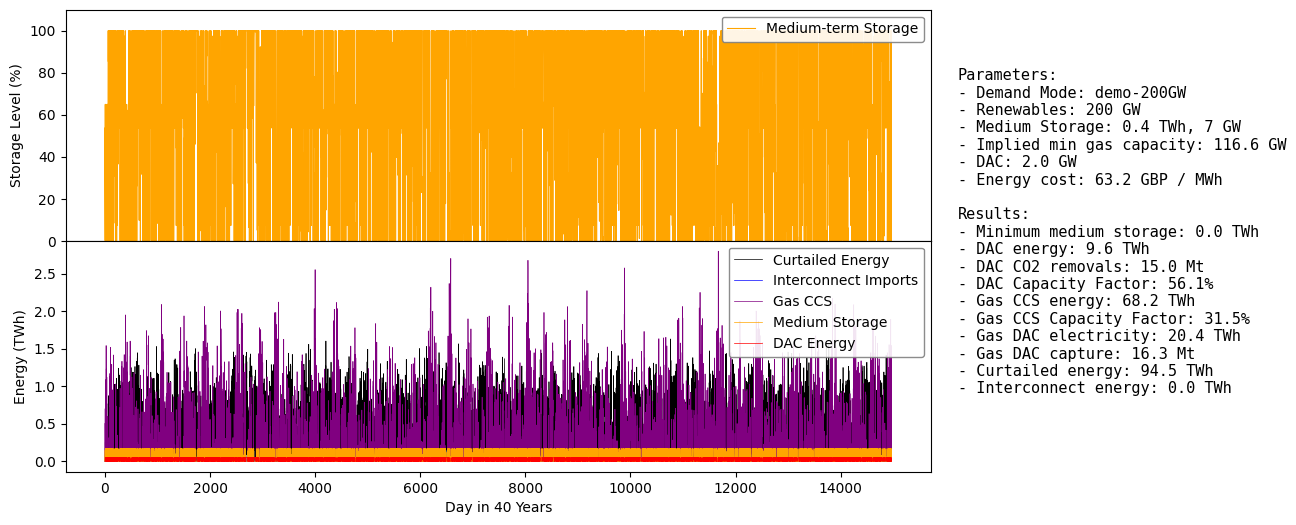

In [10]:
ps_no_h2.plot_simulation_results(sim_150, analysis_150, demand_mode="demo-200GW", fname=None)
plt.show()


### Running Checks


In [11]:
import src.assumptions as A
print("A.EnergyDemand2050 =", A.EnergyDemand2050)
print("A.CB7EnergyDemand2050 =", A.CB7EnergyDemand2050)
print("calc_energy_cost =", ps_no_h2.calculate_energy_cost(sim_150))
print("calc_power_system_cost =", ps_no_h2.calculate_power_system_cost(sim_150))


A.EnergyDemand2050 = 692 terawatt_hour
A.CB7EnergyDemand2050 = 692 terawatt_hour
calc_energy_cost = 63.16320547010622 GBP / megawatt_hour
calc_power_system_cost = 43708938185.31351 GBP


In [24]:
col = f"medium_storage_level (TWh),RC={ps_no_h2.renewable_capacity}GW"
min_val = sim_150[col].min()
min_val


<Quantity(0.0, 'terawatt_hour')>

In [14]:

gas_ccs_col = f"gas_ccs_energy (TWh),RC={int(ps_no_h2.renewable_capacity)}GW"
sim_150[gas_ccs_col].mean() * 365


<Quantity(68.2381033, 'terawatt_hour')>

In [15]:
gas_ccs_col = f"gas_ccs_energy (TWh),RC={int(ps_no_h2.renewable_capacity)}GW"
annual_gas_ccs_energy = sim_150[gas_ccs_col].mean() * 365
annual_gas_ccs_energy, A.DispatchableGasCCS.LCOE


(<Quantity(68.2381033, 'terawatt_hour')>,
 <Quantity(180.0, 'GBP / megawatt_hour')>)

In [16]:
total_cost = ps_no_h2.calculate_power_system_cost(sim_150)
energy_cost = (total_cost / A.EnergyDemand2050).to(U.GBP / U.MWh)
total_cost, energy_cost


(<Quantity(4.37089382e+10, 'GBP')>,
 <Quantity(63.1632055, 'GBP / megawatt_hour')>)

In [17]:
# Re-run after editing power_system_core_no_h2.py
from importlib import reload
import src.power_system_core_no_h2 as core_no_h2
reload(core_no_h2)

sim_150 = ps_no_h2.run_simulation(net_supply_df)

gas_ccs_col = f"gas_ccs_energy (TWh),RC={int(ps_no_h2.renewable_capacity)}GW"
annual_gas_ccs_energy = sim_150[gas_ccs_col].mean() * 365

total_cost = ps_no_h2.calculate_power_system_cost(sim_150)
energy_cost = (total_cost / A.EnergyDemand2050).to(U.GBP / U.MWh)

annual_gas_ccs_energy, total_cost, energy_cost


(<Quantity(68.2381033, 'terawatt_hour')>,
 <Quantity(4.37089382e+10, 'GBP')>,
 <Quantity(63.1632055, 'GBP / megawatt_hour')>)

In [18]:
gas_ccs_col = f"gas_ccs_energy (TWh),RC={int(ps_no_h2.renewable_capacity)}GW"
peak_gas_twh = sim_150[gas_ccs_col].max()

# If it's already a pint Quantity, just divide by HoursPerDay
min_gas_capacity = (peak_gas_twh / A.HoursPerDay).to(U.GW)

print("Peak gas CCS energy (TWh/day):", peak_gas_twh)
print("Implied minimum gas capacity (GW):", min_gas_capacity)



Peak gas CCS energy (TWh/day): 2.798627790715205 terawatt_hour
Implied minimum gas capacity (GW): 116.60949127980022 gigawatt


In [23]:


# --- Inputs (same columns used by the model) ---
rc_gw = int(ps_no_h2.renewable_capacity)
gas_ccs_col = f"gas_ccs_energy (TWh),RC={rc_gw}GW"
gas_dac_elec_col = f"gas_dac_electricity (TWh),RC={rc_gw}GW"
gas_dac_cap_col = f"gas_dac_capture (MtCO2),RC={rc_gw}GW"

gas_ccs_twh = sim_150[gas_ccs_col].astype(float).to_numpy()
gas_dac_elec_twh_sim = sim_150[gas_dac_elec_col].astype(float).to_numpy()
gas_dac_capture_mt_sim = sim_150[gas_dac_cap_col].astype(float).to_numpy()

# --- Parameters (from the model instance) ---
gas_dac_electricity_per_t = ps_no_h2.gas_dac_electricity_per_t  # MWh / t
gas_co2_intensity = ps_no_h2.gas_co2_intensity                  # t / MWh
gas_dac_heat_per_t = ps_no_h2.gas_dac_heat_per_t                # MWh / t
gas_electrical_efficiency = ps_no_h2.gas_electrical_efficiency  # fraction
gas_waste_heat_fraction = ps_no_h2.gas_waste_heat_fraction      # fraction
gas_low_temperature_fraction = ps_no_h2.gas_low_temperature_fraction  # fraction
gas_tech_is_edac = ps_no_h2.gas_tech_is_edac

# --- Step 1: gas CCS electricity output (gross), subtract DAC electricity to get net output ---
# NOTE: model logic treats gas_ccs_energy as gross output and then adds DAC electricity on top,
# so we remove DAC elec to get the net output when computing emissions.
gas_output_mwh = (gas_ccs_twh - gas_dac_elec_twh_sim) * 1e6  # TWh -> MWh

# --- Step 2: gross CO2 emissions from gas output ---
gross_emissions_t = gas_output_mwh * gas_co2_intensity  # tCO2

# --- Step 3: capture limit ---
if gas_tech_is_edac:
    # E-DAC is electricity-limited
    capture_limit_t = gas_output_mwh / gas_dac_electricity_per_t
    capture_limit_formula = "E-DAC (electricity-limited)"
else:
    # Heat-limited DAC from waste heat
    fuel_input_mwh = gas_output_mwh / gas_electrical_efficiency
    waste_heat_mwh = fuel_input_mwh * gas_waste_heat_fraction
    usable_heat_mwh = waste_heat_mwh * gas_low_temperature_fraction
    capture_limit_t = usable_heat_mwh / gas_dac_heat_per_t
    capture_limit_formula = "Heat-limited DAC (waste-heat)"

# --- Step 4: actual capture ---
capture_t = np.minimum(capture_limit_t, gross_emissions_t)

# --- Step 5: DAC electricity requirement and capture in MtCO2 ---
gas_dac_elec_twh_calc = (capture_t * gas_dac_electricity_per_t) / 1e6
gas_dac_capture_mt_calc = capture_t / 1e6

# --- Compare per-timestep ---
rtol = 1e-9
atol = 1e-9
print("Capture limit formula:", capture_limit_formula)
print("Max |Δ gas_dac_electricity| (TWh):", np.max(np.abs(gas_dac_elec_twh_calc - gas_dac_elec_twh_sim)))
print("Max |Δ gas_dac_capture| (MtCO2):", np.max(np.abs(gas_dac_capture_mt_calc - gas_dac_capture_mt_sim)))

# --- Annualization (same as analyze_simulation_results) ---
annual_gas_dac_capture_calc = gas_dac_capture_mt_calc.mean() * 365
print("annual_gas_dac_capture (calc):", annual_gas_dac_capture_calc)
print("annual_gas_dac_capture (results):", analysis_150["annual_gas_dac_capture"])




Capture limit formula: E-DAC (electricity-limited)
Max |Δ gas_dac_electricity| (TWh): 3.3306690738754696e-16
Max |Δ gas_dac_capture| (MtCO2): 1.6653345369377348e-16
annual_gas_dac_capture (calc): 16.281372012048113
annual_gas_dac_capture (results): 16.28137201204811 megametric_ton
